## **BLINKIT ANALYSIS**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Raw Data**

In [3]:
df=pd.read_csv("C:/Users/praji/Downloads/blinkit_analysis.csv")

In [3]:
df.head(10)

,Item_Identifier,Item_Fat_Content,Item_Type,Item_Visibility,Item_Weight,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Location_Type,Outlet_Size,Outlet_Type,Total_Sales,Rating
0,ITM001,No Fat,Fruits & Veg,0.147,7.25,OUT007,1987,Rural,Medium,Grocery Store,740.81,1
1,ITM002,No Fat,Soft Drinks,0.269,17.39,OUT001,2007,Rural,Medium,Grocery Store,1522.14,1
2,ITM003,Low Fat,Household,0.275,16.96,OUT009,1988,Urban,Medium,Supermarket Type2,2204.16,1
3,ITM004,Regular,Household,0.161,18.20,OUT006,2009,Rural,Medium,Grocery Store,2073.85,1
4,ITM005,Regular,Fruits & Veg,0.337,13.68,OUT009,1992,Rural,High,Grocery Store,1461.31,5
5,ITM006,Low Fat,Fruits & Veg,0.246,11.76,OUT007,1989,Rural,Medium,Supermarket Type1,4197.96,2
6,ITM007,Regular,Canned,0.328,10.54,OUT009,2007,Urban,Small,Supermarket Type1,1543.86,4
7,ITM008,No Fat,Household,0.151,7.74,OUT006,1994,Semi-Urban,Medium,Grocery Store,4653.12,2
8,ITM009,Regular,Snack Foods,0.166,15.87,OUT009,2010,Urban,High,Supermarket Type1,1864.75,2
9,ITM010,Regular,Soft Drinks,0.183,8.09,OUT007,1985,Semi-Urban,High,Grocery Store,2462.72,1


In [4]:
df.tail(10)

,Item_Identifier,Item_Fat_Content,Item_Type,Item_Visibility,Item_Weight,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Location_Type,Outlet_Size,Outlet_Type,Total_Sales,Rating
790,ITM1690,No Fat,Household,0.362,9.73,OUT004,2008,Rural,Small,Supermarket Type1,3034.11,1
791,ITM1691,Regular,Soft Drinks,0.098,5.35,OUT007,2003,Urban,Medium,Supermarket Type2,1063.33,3
792,ITM1692,No Fat,Soft Drinks,0.092,15.03,OUT006,1996,Urban,Small,Supermarket Type1,3860.59,4
793,ITM1693,Low Fat,Baking Goods,0.305,19.43,OUT009,2004,Rural,Small,Supermarket Type1,1400.52,4
794,ITM1694,Regular,Frozen Foods,0.348,19.43,OUT004,2009,Rural,Medium,Grocery Store,1637.81,5
795,ITM1695,Low Fat,Snack Foods,0.056,11.08,OUT003,1995,Semi-Urban,High,Grocery Store,3249.20,3
796,ITM1696,Regular,Canned,0.253,12.92,OUT008,1994,Urban,Small,Supermarket Type1,1654.16,4
797,ITM1697,Regular,Snack Foods,0.116,10.27,OUT010,2006,Semi-Urban,High,Supermarket Type2,3932.60,1
798,ITM1698,Regular,Dairy,0.258,9.28,OUT009,2003,Rural,Medium,Grocery Store,1236.46,4
799,ITM1699,Low Fat,Soft Drinks,0.128,11.29,OUT003,2004,Urban,High,Supermarket Type1,867.18,5


## **Field information**

In [5]:
print("size of data is",df.shape)

size of data is (800, 12)


In [6]:
df.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Item_Visibility',
       'Item_Weight', 'Outlet_Identifier', 'Outlet_Establishment_Year',
       'Outlet_Location_Type', 'Outlet_Size', 'Outlet_Type', 'Total_Sales',
       'Rating'],
      dtype='object')

## **Data types**

In [7]:
df.dtypes

Item_Identifier               object
Item_Fat_Content              object
Item_Type                     object
Item_Visibility              float64
Item_Weight                  float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Location_Type          object
Outlet_Size                   object
Outlet_Type                   object
Total_Sales                  float64
Rating                         int64
dtype: object

## **Data Cleaninig**

In [8]:
print(df['Item_Fat_Content'].unique())

['No Fat' 'Low Fat' 'Regular']


In [9]:
df['Item_Fat_Content']=df['Item_Fat_Content'].replace({'No Fat':'Low Fat'})

## **Data Cleaninig**

## KPI's REQUIRMENTS

In [10]:
#Total Sales
Total_Sales = df['Total_Sales'].sum()

#Average Sales 
avg_sales = df['Total_Sales'].mean()


#no of items sold
no_of_items_sold =  df['Total_Sales'].count()

#average rating
avg_ratings = df['Rating'].mean()

#display

print(f"Total Sales: ${Total_Sales:,.0f}")

print(f"avg_sales: ${avg_sales:,.0f}")

print(f"no_of_items_solds: {no_of_items_sold:,.0f}")

print(f"avg_ratings: {avg_ratings:,.0f}")

Total Sales: $1,809,891
avg_sales: $2,262
no_of_items_solds: 800
avg_ratings: 3


## **CHARTS REQUIREMENTS**

#### **Total Sales By Fat Content**

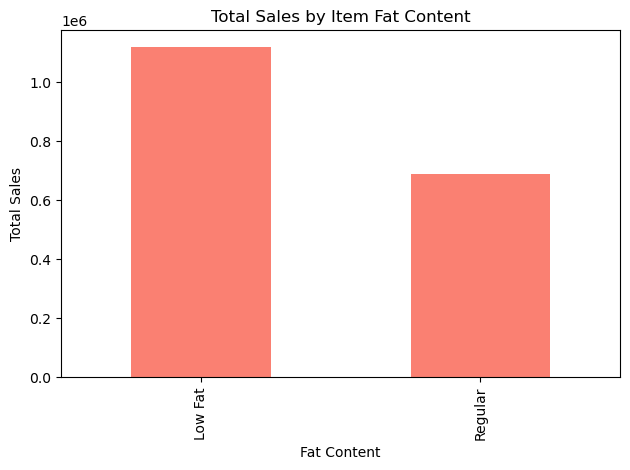

In [11]:
 df.groupby('Item_Fat_Content')['Total_Sales'].sum().sort_values(ascending=False).plot(kind='bar', color='salmon', title='Total Sales by Item Fat Content'); plt.xlabel('Fat Content'); plt.ylabel('Total Sales'); plt.tight_layout(); plt.show()


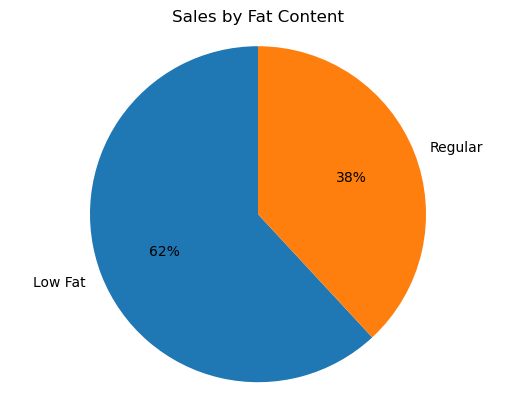

In [12]:
sales_by_fat = df.groupby('Item_Fat_Content')['Total_Sales'].sum()
plt.pie(sales_by_fat, labels=sales_by_fat.index, autopct='%1.0f%%', startangle=90)
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()


#### **Total Sales By Item Type**

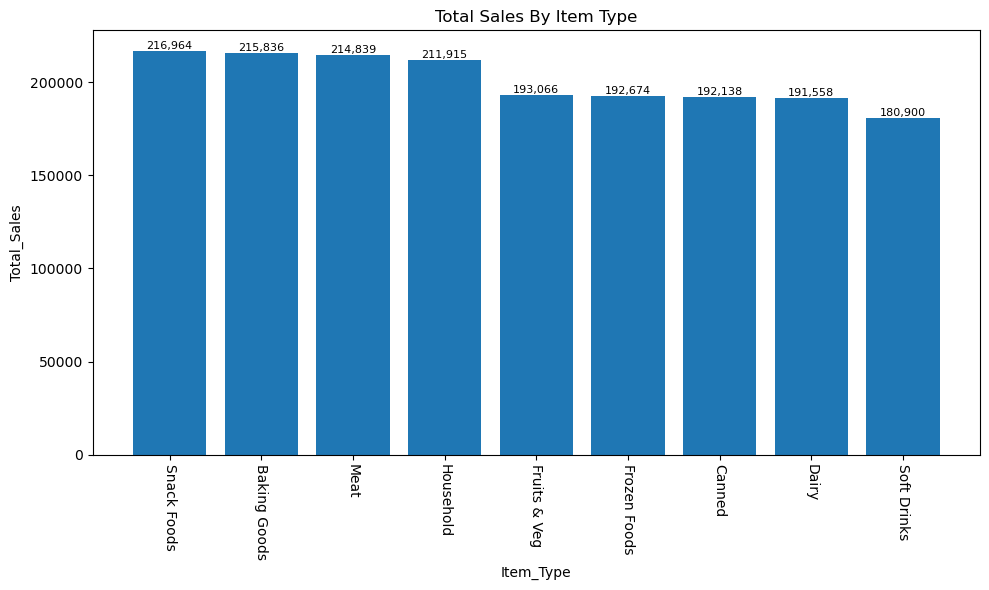

In [23]:
sales_by_type = df.groupby('Item_Type')['Total_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars=plt.bar(sales_by_type.index,sales_by_type.values)


plt.xticks(rotation=-90)
plt.xlabel('Item_Type')
plt.ylabel('Total_Sales')
plt.title('Total Sales By Item Type')

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height(),
             f'{bar.get_height():,.0f}', ha='center', va='bottom',fontsize=8)

plt.tight_layout()
plt.show()

## *Fat Content By Outlet By Total Sales*

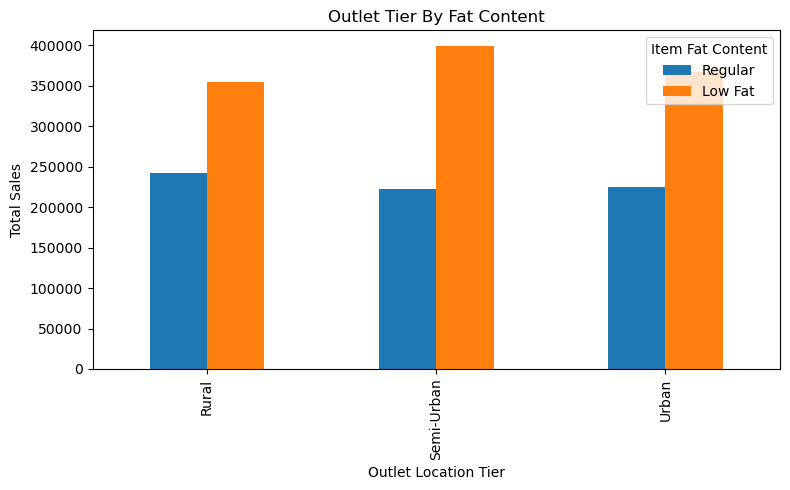

In [19]:
grouped = df.groupby(['Outlet_Location_Type', 'Item_Fat_Content'])['Total_Sales'].sum().unstack()
grouped = grouped[['Regular', 'Low Fat']]

ax = grouped.plot(kind='bar', figsize=(8,5), title='Outlet Tier By Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()



## *Total Sales By Outlet Establishment*

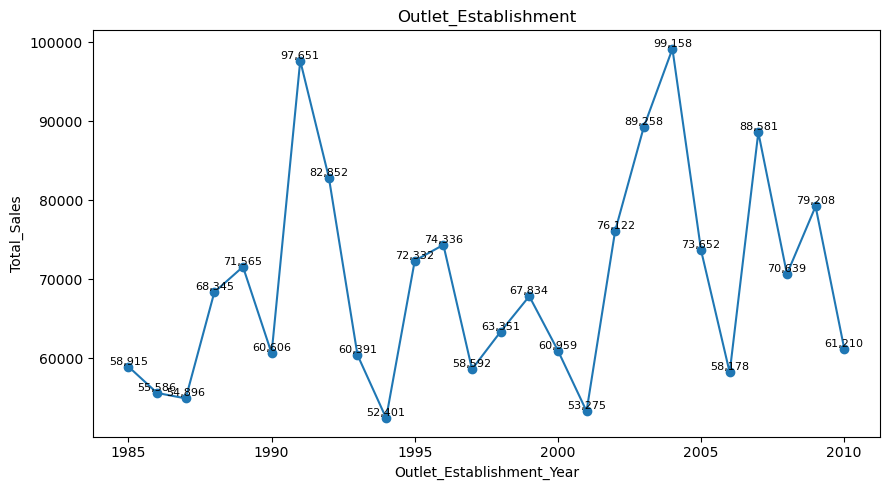

In [24]:
sales_by_year = df.groupby('Outlet_Establishment_Year')['Total_Sales'].sum().sort_index()

plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index,sales_by_year.values,marker='o',linestyle='-')

plt.xlabel('Outlet_Establishment_Year')
plt.ylabel('Total_Sales')
plt.title('Outlet_Establishment')

for x,y in zip(sales_by_year.index,sales_by_year.values):
    plt.text(x,y,f'{y:,.0f}',ha='center', va='bottom',fontsize=8)

plt.tight_layout()
plt.show()


## *Sales By Outlet Size*

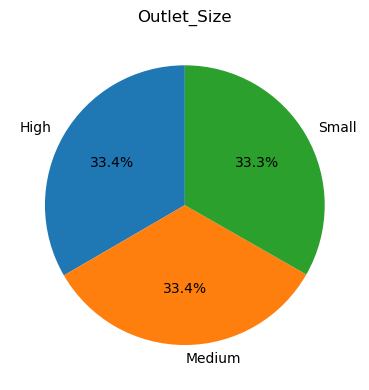

In [26]:
sales_by_size = df.groupby('Outlet_Size')['Total_Sales'].sum()

plt.figure(figsize=(4,4))
plt.pie(sales_by_size,labels=sales_by_size.index,autopct='%1.1f%%', startangle=90)

plt.title('Outlet_Size')
plt.tight_layout()
plt.show()


## *Sales By Outlet Location*

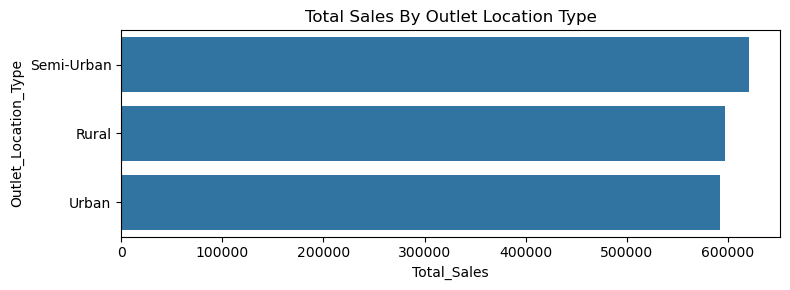

In [4]:
sales_by_location = df.groupby('Outlet_Location_Type')['Total_Sales'].sum().reset_index()
sales_by_location = sales_by_location.sort_values('Total_Sales',ascending=False)

plt.figure(figsize=(8,3))
ax = sns.barplot(x='Total_Sales',y ='Outlet_Location_Type',data=sales_by_location)

plt.title('Total Sales By Outlet Location Type')
plt.xlabel('Total_Sales')
plt.ylabel('Outlet_Location_Type')
plt.tight_layout()
plt.show()


